In [1]:
pip install pandas matplotlib seaborn Pillow

Note: you may need to restart the kernel to use updated packages.


## Trực quan hóa + phân tích size ảnh

🔍 Đang quét thư mục: d:\Machine Learning\ML-Lab01\data\images
📂 Đang xử lý thư mục: images (8000 ảnh)


100%|██████████| 8000/8000 [00:55<00:00, 145.15it/s]


✅ Đã quét thành công 8000 ảnh.

--- THỐNG KÊ CHI TIẾT ---
             width       height  aspect_ratio
count  8000.000000  8000.000000   8000.000000
mean    896.585250   461.402000      1.748357
std     583.483659   162.503502      0.693689
min     176.000000   133.000000      0.562500
25%     224.000000   224.000000      1.000000
50%     640.000000   480.000000      1.498829
75%    1622.000000   626.000000      2.591054
max    1622.000000   640.000000      4.812030


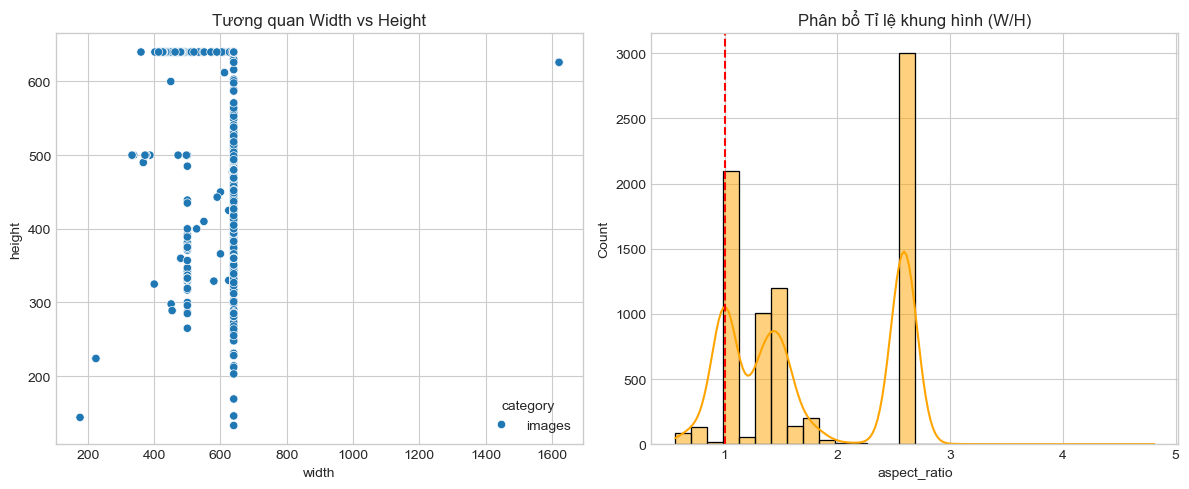

In [4]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 1. Tự động lấy đường dẫn tuyệt đối để tránh lỗi đường dẫn tương đối
# Đảm bảo bạn đang đứng ở thư mục gốc chứa folder DATA
IMAGE_FOLDER = os.path.abspath('images') 

print(f"🔍 Đang quét thư mục: {IMAGE_FOLDER}")

def analyze_image_sizes(folder_path):
    data = []
    if not os.path.exists(folder_path):
        print(f"❌ LỖI: Thư mục '{folder_path}' không tồn tại!")
        return pd.DataFrame()

    # Duyệt qua các thư mục con
    for root, dirs, files in os.walk(folder_path):
        # Chỉ lấy các file là ảnh
        img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if img_files:
            print(f"📂 Đang xử lý thư mục: {os.path.basename(root)} ({len(img_files)} ảnh)")
            for filename in tqdm(img_files):
                filepath = os.path.join(root, filename)
                try:
                    with Image.open(filepath) as img:
                        width, height = img.size
                        data.append({
                            'filename': filename,
                            'width': width,
                            'height': height,
                            'aspect_ratio': width / height,
                            'category': os.path.basename(root)
                        })
                except Exception as e:
                    pass # Bỏ qua nếu file ảnh lỗi

    return pd.DataFrame(data)

# Chạy hàm phân tích
df = analyze_image_sizes(IMAGE_FOLDER)

# 2. Kiểm tra nếu tìm thấy ảnh mới chạy tiếp
if df.empty:
    print("❌ KHÔNG TÌM THẤY ẢNH NÀO! Vui lòng kiểm tra lại đường dẫn folder images.")
else:
    print(f"✅ Đã quét thành công {len(df)} ảnh.")
    
    # In thống kê
    print("\n--- THỐNG KÊ CHI TIẾT ---")
    print(df[['width', 'height', 'aspect_ratio']].describe())

    # Vẽ biểu đồ
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Biểu đồ 1: Scatter plot
    sns.scatterplot(data=df, x='width', y='height', hue='category', ax=axes[0])
    axes[0].set_title('Tương quan Width vs Height')

    # Biểu đồ 2: Histogram Tỉ lệ khung hình
    sns.histplot(df['aspect_ratio'], bins=30, kde=True, color='orange', ax=axes[1])
    axes[1].axvline(1.0, color='red', linestyle='--')
    axes[1].set_title('Phân bổ Tỉ lệ khung hình (W/H)')

    plt.tight_layout()
    plt.show()

# Thực hiện resize ảnh cho phù hợp
- Khống chế cạnh dài cao nhất 1024
- Đảm bảo cạnh ngắn ít nhất 224

In [5]:
import os
from PIL import Image
from tqdm import tqdm

INPUT_DIR = 'images'
OUTPUT_DIR = 'images_preprocessed'
MAX_SIZE = 1024   # Ngưỡng trên cho cạnh dài
MIN_SHORT_SIDE = 224 # Ngưỡng dưới cho cạnh ngắn (đảm bảo đủ thông tin cho mô hình)

def preprocess_images():
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    img_files_total = []
    for root, dirs, files in os.walk(INPUT_DIR):
        img_files_total.extend([(root, f) for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    print(f"🚀 Bắt đầu xử lý {len(img_files_total)} ảnh...")

    for root, filename in tqdm(img_files_total):
        try:
            # Tạo đường dẫn output đồng nhất với cấu trúc input
            rel_path = os.path.relpath(root, INPUT_DIR)
            target_path = os.path.join(OUTPUT_DIR, rel_path)
            if not os.path.exists(target_path):
                os.makedirs(target_path)

            img_path = os.path.join(root, filename)
            with Image.open(img_path) as img:
                img = img.convert('RGB')
                w, h = img.size
                
                scale = 1.0
                
                # QUY TẮC 1: Nếu quá lớn -> Thu nhỏ lại (dựa trên cạnh dài)
                if max(w, h) > MAX_SIZE:
                    scale = MAX_SIZE / max(w, h)
                
                # QUY TẮC 2: Nếu quá nhỏ -> Phóng to lên (dựa trên cạnh ngắn)
                # Lưu ý: Quy tắc này được ưu tiên sau để đảm bảo ảnh luôn đủ chất lượng
                elif min(w, h) < MIN_SHORT_SIDE:
                    scale = MIN_SHORT_SIDE / min(w, h)
                
                # Thực hiện resize nếu cần
                if scale != 1.0:
                    new_w = int(w * scale)
                    new_h = int(h * scale)
                    img = img.resize((new_w, new_h), Image.LANCZOS)
                
                # Lưu ảnh dưới định dạng .jpg chất lượng cao
                save_name = os.path.splitext(filename)[0] + ".jpg"
                img.save(os.path.join(target_path, save_name), "JPEG", quality=90)
                
        except Exception as e:
            print(f"❌ Lỗi ảnh {filename}: {e}")

preprocess_images()

🚀 Bắt đầu xử lý 8000 ảnh...


100%|██████████| 8000/8000 [02:54<00:00, 45.85it/s] 


## Trực quan hóa + kiểm chứng ảnh sau resize 

📂 Đang xử lý thư mục: images_preprocessed (8000 ảnh)


100%|██████████| 8000/8000 [01:10<00:00, 113.63it/s]


✅ Đã quét thành công 8000 ảnh.

--- THỐNG KÊ CHI TIẾT ---
             width       height  aspect_ratio
count  8000.000000  8000.000000   8000.000000
mean    672.487000   374.820250      1.748862
std     314.503772   101.878174      0.694302
min     224.000000   223.000000      0.562500
25%     260.750000   224.000000      1.000000
50%     640.000000   395.000000      1.498829
75%    1024.000000   427.000000      2.592405
max    1077.000000   640.000000      4.808036


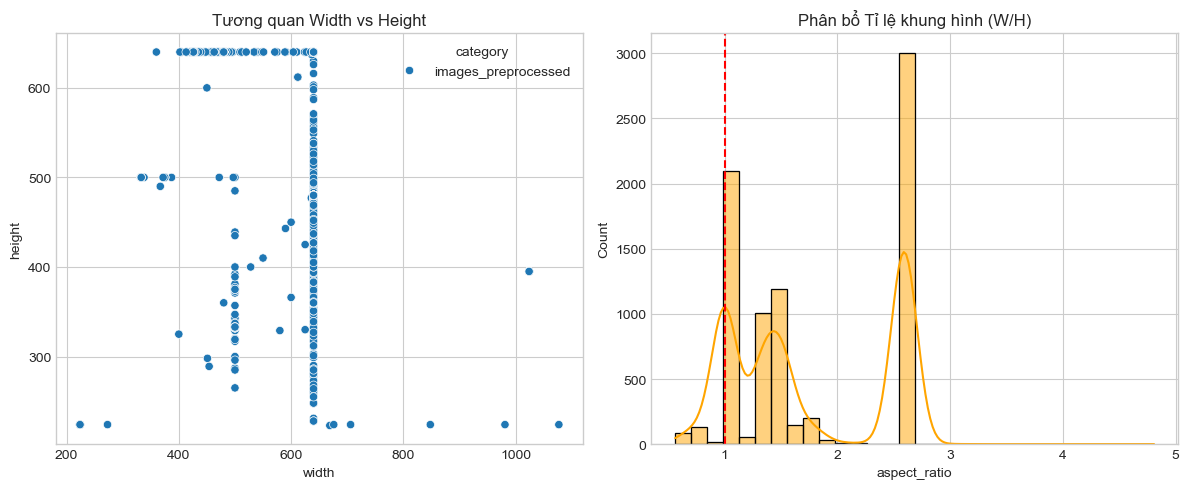

In [6]:
IMAGE_FOLDER = os.path.abspath('images_preprocessed') 

# Chạy hàm phân tích
df = analyze_image_sizes(IMAGE_FOLDER)

# 2. Kiểm tra nếu tìm thấy ảnh mới chạy tiếp
if df.empty:
    print("❌ KHÔNG TÌM THẤY ẢNH NÀO! Vui lòng kiểm tra lại đường dẫn folder images.")
else:
    print(f"✅ Đã quét thành công {len(df)} ảnh.")
    
    # In thống kê
    print("\n--- THỐNG KÊ CHI TIẾT ---")
    print(df[['width', 'height', 'aspect_ratio']].describe())

    # Vẽ biểu đồ
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Biểu đồ 1: Scatter plot
    sns.scatterplot(data=df, x='width', y='height', hue='category', ax=axes[0])
    axes[0].set_title('Tương quan Width vs Height')

    # Biểu đồ 2: Histogram Tỉ lệ khung hình
    sns.histplot(df['aspect_ratio'], bins=30, kde=True, color='orange', ax=axes[1])
    axes[1].axvline(1.0, color='red', linestyle='--')
    axes[1].set_title('Phân bổ Tỉ lệ khung hình (W/H)')

    plt.tight_layout()
    plt.show()

## Thực hiện phân tách tập train, val, test trong file json
- Áp dụng phương pháp Stratified Split (Phân tầng) để đảm bảo rằng dù là ở tập Train, Val hay Test, mô hình đều được tiếp xúc với tỷ lệ đồng đều của các loại môi trường

In [2]:
import json
import random

# 1. Load dữ liệu gốc
with open('labels_final_v2.json', 'r', encoding='utf-8') as f:
    full_data = json.load(f)

# Tạo dictionary để truy cập nhanh theo tên file
data_dict = {item['image']: item for item in full_data}

# 2. Định nghĩa các dải ID cho từng nhóm (Helper function)
def get_id(filename):
    return int(filename.split('.')[0])

# Phân loại ảnh vào các túi (buckets)
buckets = {
    'street': [f"{i:05d}.jpg" for i in range(1, 3001)],
    'transport': [f"{i:05d}.jpg" for i in range(3001, 6001)],
    'bathroom': [f"{i:05d}.jpg" for i in range(6001, 6201)] + [f"{i:05d}.jpg" for i in range(7001, 7201)],
    'dining': [f"{i:05d}.jpg" for i in range(6201, 6401)] + [f"{i:05d}.jpg" for i in range(7201, 7401)],
    'living': [f"{i:05d}.jpg" for i in range(6401, 6601)] + [f"{i:05d}.jpg" for i in range(7601, 7801)],
    'kitchen': [f"{i:05d}.jpg" for i in range(6601, 6801)] + [f"{i:05d}.jpg" for i in range(7801, 8001)],
    'bedroom': [f"{i:05d}.jpg" for i in range(6801, 7001)] + [f"{i:05d}.jpg" for i in range(7401, 7601)]
}

train_imgs, val_imgs, test_imgs = [], [], []

# 3. Thực hiện chia phân tầng
random.seed(42) # Cố định kết quả chia
for cat, img_list in buckets.items():
    random.shuffle(img_list)
    n = len(img_list)
    train_end = int(n * 0.8)
    val_end = train_end + int(n * 0.1)
    
    train_imgs.extend(img_list[:train_end])
    val_imgs.extend(img_list[train_end:val_end])
    test_imgs.extend(img_list[val_end:])

# 4. Gộp dữ liệu captions tương ứng
def build_split(img_list):
    # Chỉ lấy những ảnh thực sự tồn tại trong file JSON nhãn
    return [data_dict[img] for img in img_list if img in data_dict]

train_set = build_split(train_imgs)
val_set = build_split(val_imgs)
test_set = build_split(test_imgs)

# 5. Lưu kết quả
with open('train.json', 'w', encoding='utf-8') as f: json.dump(train_set, f, ensure_ascii=False, indent=2)
with open('val.json', 'w', encoding='utf-8') as f: json.dump(val_set, f, ensure_ascii=False, indent=2)
with open('test.json', 'w', encoding='utf-8') as f: json.dump(test_set, f, ensure_ascii=False, indent=2)

print(f"✅ Đã chia xong!")
print(f"Train: {len(train_set)} ảnh | Val: {len(val_set)} ảnh | Test: {len(test_set)} ảnh")

✅ Đã chia xong!
Train: 6400 ảnh | Val: 800 ảnh | Test: 800 ảnh


## Thực hiện tách folder ảnh thành tập train, val, test theo kết quả bước trên

In [3]:
import os
import json
import shutil
from tqdm import tqdm

# Cấu hình đường dẫn
ORIGINAL_IMG_DIR = 'images_preprocessed'
OUTPUT_BASE_DIR = 'final_dataset' # Thư mục chuẩn để up lên Hugging Face
SPLIT_FILES = {
    'train': 'train.json',
    'val': 'val.json',
    'test': 'test.json'
}

def split_images_physically():
    # 1. Tạo cấu trúc thư mục mới
    for split in SPLIT_FILES.keys():
        os.makedirs(os.path.join(OUTPUT_BASE_DIR, split), exist_ok=True)

    # 2. Duyệt qua từng tập để copy ảnh
    for split, json_path in SPLIT_FILES.items():
        print(f"🚚 Đang di chuyển ảnh cho tập {split}...")
        
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        for item in tqdm(data):
            img_name = item['image']
            
            # Tìm đường dẫn gốc của ảnh (vì ảnh có thể nằm trong folder con street/transport/house)
            found = False
            for root, dirs, files in os.walk(ORIGINAL_IMG_DIR):
                if img_name in files:
                    src_path = os.path.join(root, img_name)
                    dst_path = os.path.join(OUTPUT_BASE_DIR, split, img_name)
                    
                    # Copy ảnh sang thư mục mới
                    shutil.copy2(src_path, dst_path)
                    found = True
                    break
            
            if not found:
                print(f"⚠️ Cảnh báo: Không tìm thấy ảnh {img_name} trong thư mục gốc!")

    print(f"\n✅ Hoàn thành! Dữ liệu đã sẵn sàng tại: {OUTPUT_BASE_DIR}")

split_images_physically()

🚚 Đang di chuyển ảnh cho tập train...


100%|██████████| 6400/6400 [00:29<00:00, 218.03it/s]


🚚 Đang di chuyển ảnh cho tập val...


100%|██████████| 800/800 [00:03<00:00, 220.71it/s]


🚚 Đang di chuyển ảnh cho tập test...


100%|██████████| 800/800 [00:03<00:00, 228.26it/s]


✅ Hoàn thành! Dữ liệu đã sẵn sàng tại: final_dataset


## Tạo file metadata.json theo đúng chuẩn HuggingFace cho từng tập train, val, test

In [1]:
import json
import os

final_data_path = os.path.join("final_dataset")
splits = ['train', 'val', 'test']

for split in splits:
    json_input = os.path.join(f"{split}.json")
    jsonl_output = os.path.join(final_data_path, split, "metadata.jsonl")
    
    print(f"🔄 Đang tạo metadata cho tập {split}...")
    
    with open(json_input, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    with open(jsonl_output, 'w', encoding='utf-8') as f:
        for item in data:
            # Hugging Face chuẩn: {"file_name": "0001.jpg", "text": ["cap1", "cap2",...]}
            # Hoặc bạn có thể để text là 1 chuỗi nếu muốn train nhanh
            entry = {
                "file_name": item['image'],
                "text": [c['caption'] for c in item['captions']] # Lưu cả 5 captions vào 1 list
            }
            f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print("✅ Đã chuẩn bị xong file metadata.jsonl trong các thư mục con!")

🔄 Đang tạo metadata cho tập train...
🔄 Đang tạo metadata cho tập val...
🔄 Đang tạo metadata cho tập test...
✅ Đã chuẩn bị xong file metadata.jsonl trong các thư mục con!


## Tiến hành đưa dataset lên HuggingFace

In [1]:
!pip install -U huggingface_hub

In [ ]:
from huggingface_hub import login

login(token="hf_*******************") 

In [5]:
from huggingface_hub import HfApi, create_repo

api = HfApi()

# 1. Cấu hình thông tin
repo_id = "pqthinh232/HCMUS-Vietnamese-Image-captioning-for-blind"
folder_path = "final_dataset" 

try:
    # 2. Tự động tạo Repo nếu chưa tồn tại
    print(f"🔄 Đang kiểm tra/tạo repository: {repo_id}...")
    create_repo(repo_id=repo_id, repo_type="dataset", exist_ok=True)

    # 3. Bắt đầu upload
    print(f"🚀 Đang bắt đầu upload dữ liệu lên {repo_id}...")
    api.upload_folder(
        folder_path=folder_path,
        repo_id=repo_id,
        repo_type="dataset",
    )
    print("🎉 Chúc mừng nhóm! Dữ liệu 8.000 ảnh đã được upload thành công lên Hugging Face.")

except Exception as e:
    print(f"❌ Có lỗi xảy ra: {e}")

🔄 Đang kiểm tra/tạo repository: pqthinh232/HCMUS-Vietnamese-Image-captioning-for-blind...
🚀 Đang bắt đầu upload dữ liệu lên pqthinh232/HCMUS-Vietnamese-Image-captioning-for-blind...


It seems you are trying to upload a large folder at once. This might take some time and then fail if the folder is too large. For such cases, it is recommended to upload in smaller batches or to use `HfApi().upload_large_folder(...)`/`hf upload-large-folder` instead. For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/upload#upload-a-large-folder.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

🎉 Chúc mừng nhóm! Dữ liệu 8.000 ảnh đã được upload thành công lên Hugging Face.
